In [8]:
import pandas as pd
import numpy as np

In [9]:
file = "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_adaptive_gt_1/gt_analysis_result_5.json"

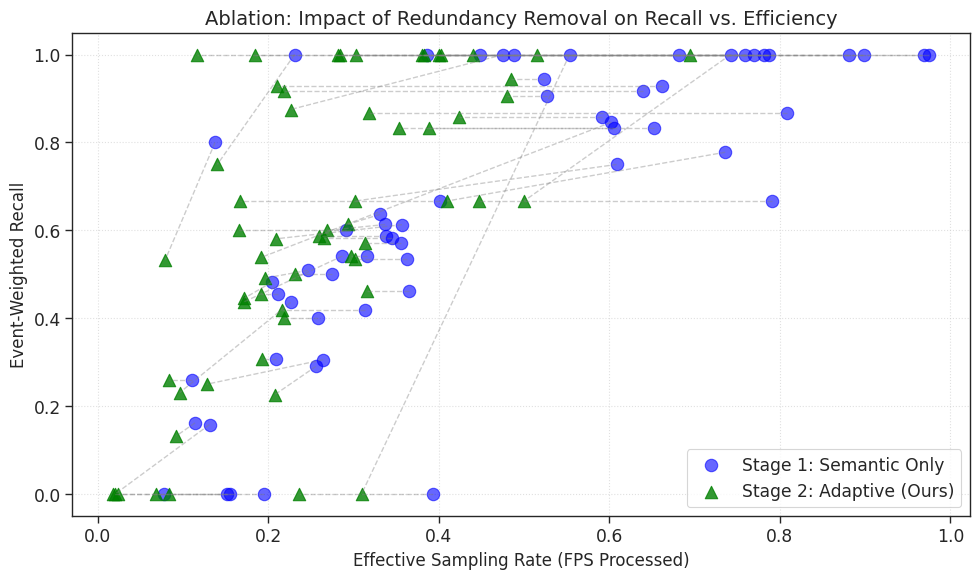

In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
with open(file, 'r') as f:
    data = json.load(f)
df = pd.DataFrame(data)

# Calculate Effective FPS (Frames Processed Per Second of Video)
df['stage1_fps'] = (df['stage1_frames_of_uniform_pct'] * df['duration']) / df['duration'] # Simplified
# Note: Using the exact frame counts derived from percentages
df['adaptive_fps'] = (df['frames_kept_pct'] * df['total_frames']) / df['duration']
# Recover Stage 1 FPS based on the ratio provided in JSON
df['stage1_fps'] = df['adaptive_fps'] * (df['stage1_frames_of_uniform_pct'] / df['adaptive_frames_of_uniform_pct'])

# Filter for relevant long videos (600s and 3600s)
df_long = df[df['duration_group'].isin([600, 3600])]

# Plotting
plt.figure(figsize=(10, 6))

# Scatter Points
plt.scatter(df_long['stage1_fps'], df_long['stage1_weighted_recall'], 
            color='blue', alpha=0.6, label='Stage 1: Semantic Only', marker='o', s=80)
plt.scatter(df_long['adaptive_fps'], df_long['adaptive_weighted_recall'], 
            color='green', alpha=0.8, label='Stage 2: Adaptive (Ours)', marker='^', s=80)

# Connect the paired points to show the "Optimization Trajectory"
for i in df_long.index:
    plt.plot([df_long.loc[i, 'stage1_fps'], df_long.loc[i, 'adaptive_fps']],
             [df_long.loc[i, 'stage1_weighted_recall'], df_long.loc[i, 'adaptive_weighted_recall']],
             color='gray', alpha=0.4, linestyle='--', linewidth=1)

# Formatting
plt.xlabel('Effective Sampling Rate (FPS Processed)', fontsize=12)
plt.ylabel('Event-Weighted Recall', fontsize=12)
plt.title('Ablation: Impact of Redundancy Removal on Recall vs. Efficiency', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save
plt.savefig('ablation_recall_fps.pdf', format='pdf')
plt.show()

/tmp/ipykernel_3760924/3713651772.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='Duration Category', y='Recall', hue='Method', data=df_melted, order=order,


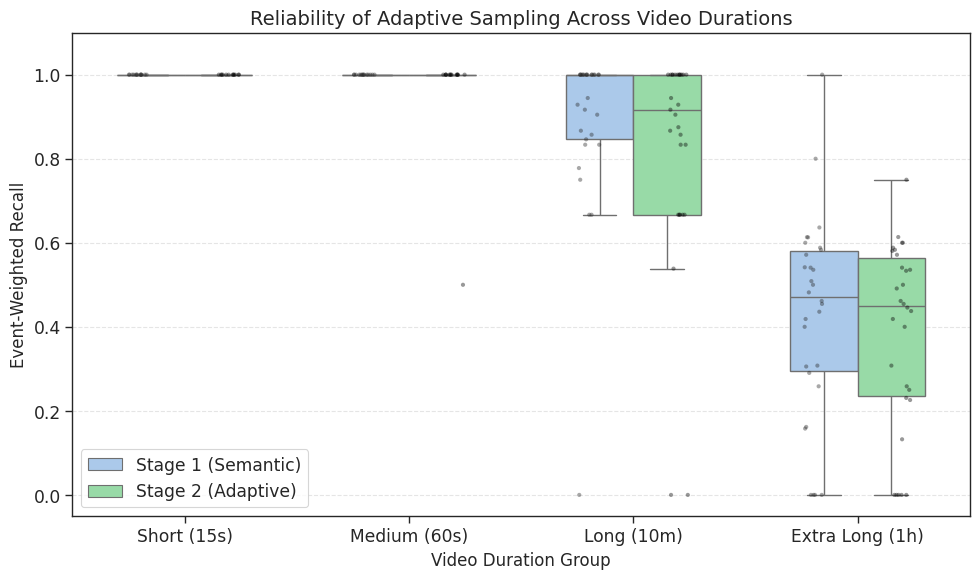

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
with open(file, 'r') as f:
    data = json.load(f)
df = pd.DataFrame(data)

# Create readable labels
duration_map = {15: 'Short (15s)', 60: 'Medium (60s)', 600: 'Long (10m)', 3600: 'Extra Long (1h)'}
df['Duration Category'] = df['duration_group'].map(duration_map)

# Melt for plotting side-by-side
df_melted = df.melt(id_vars=['Duration Category', 'duration_group'], 
                    value_vars=['stage1_weighted_recall', 'adaptive_weighted_recall'],
                    var_name='Method', value_name='Recall')

df_melted['Method'] = df_melted['Method'].replace({
    'stage1_weighted_recall': 'Stage 1 (Semantic)',
    'adaptive_weighted_recall': 'Stage 2 (Adaptive)'
})

# Plotting
plt.figure(figsize=(10, 6))
order = ['Short (15s)', 'Medium (60s)', 'Long (10m)', 'Extra Long (1h)']

# Box Plot for Distribution
sns.boxplot(x='Duration Category', y='Recall', hue='Method', data=df_melted, order=order,
            palette=['#a1c9f4', '#8de5a1'], width=0.6, showfliers=False)

# Strip Plot for Individual Data Points (shows density)
sns.stripplot(x='Duration Category', y='Recall', hue='Method', data=df_melted, order=order,
              dodge=True, color='black', alpha=0.4, size=3, jitter=True)

# Formatting
plt.title('Reliability of Adaptive Sampling Across Video Durations', fontsize=14)
plt.ylabel('Event-Weighted Recall', fontsize=12)
plt.xlabel('Video Duration Group', fontsize=12)
plt.ylim(-0.05, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Fix Legend (remove duplicate strip plot handles)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], loc='lower left', frameon=True)

plt.tight_layout()
plt.savefig('reliability_duration_box.pdf', format='pdf')
plt.show()

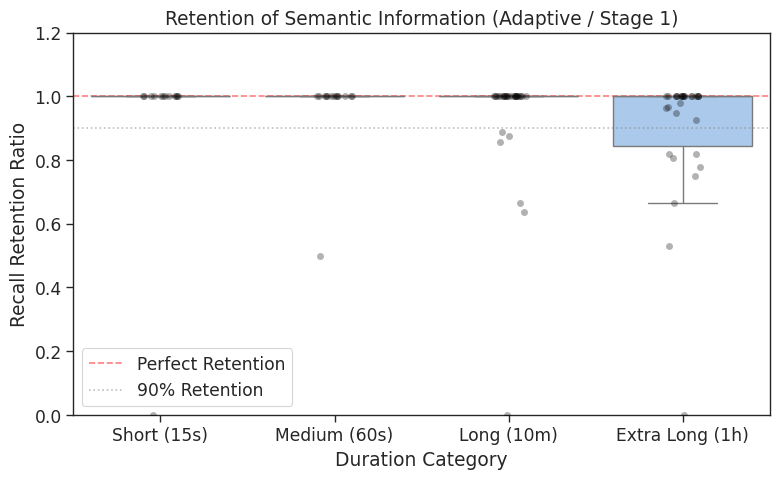

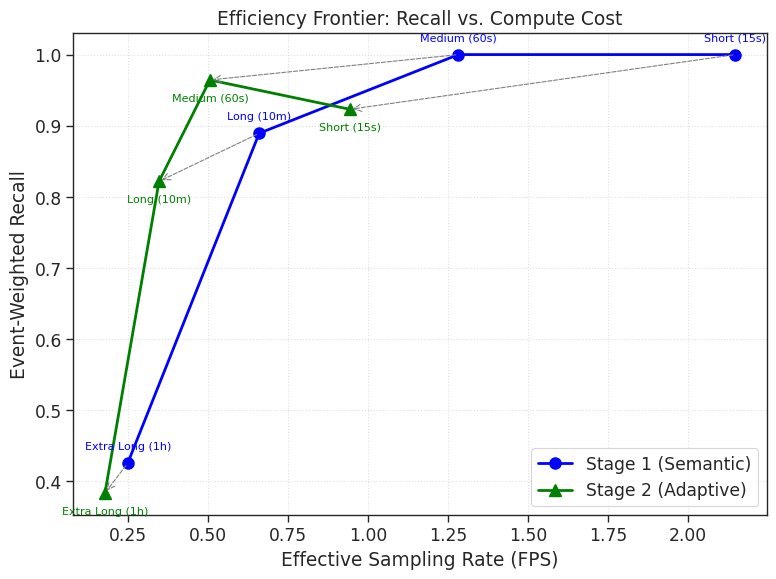

Retention Stats:
                count      mean       std  min       25%  50%  75%  max
duration_group                                                         
15               13.0  0.923077  0.277350  0.0  1.000000  1.0  1.0  1.0
60               14.0  0.964286  0.133631  0.5  1.000000  1.0  1.0  1.0
600              29.0  0.928416  0.202054  0.0  1.000000  1.0  1.0  1.0
3600             30.0  0.898278  0.207486  0.0  0.844886  1.0  1.0  1.0


In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
with open(file, 'r') as f:
    data = json.load(f)
df = pd.DataFrame(data)

# Calculate Retention (Relative Recall)
# Handle cases where Stage 1 Recall is 0 (avoid div by zero)
# If Stage 1 is 0 and Adaptive is 0, retention is 1.0 (perfectly matched nothing).
# If Stage 1 is 0 and Adaptive > 0, retention is infinite (technically >1.0, cap at 1.1 or drop).
df['retention'] = df.apply(lambda row: 1.0 if row['stage1_weighted_recall'] == 0 else row['adaptive_weighted_recall'] / row['stage1_weighted_recall'], axis=1)

# Clip retention at 1.0 or slightly above for visualization (sometimes Adaptive > Stage 1 due to noise/tolerance)
df['retention_clipped'] = df['retention'].clip(upper=1.1)

# Duration labels
duration_map = {15: 'Short (15s)', 60: 'Medium (60s)', 600: 'Long (10m)', 3600: 'Extra Long (1h)'}
df['Duration Category'] = df['duration_group'].map(duration_map)

# --- Plot 1: Retention vs. Duration (Box Plot of Relative Performance) ---
plt.figure(figsize=(8, 5))
order = ['Short (15s)', 'Medium (60s)', 'Long (10m)', 'Extra Long (1h)']
sns.boxplot(x='Duration Category', y='retention', data=df, order=order, color='#a1c9f4', showfliers=False)
sns.stripplot(x='Duration Category', y='retention', data=df, order=order, color='black', alpha=0.3, jitter=True)
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Perfect Retention')
plt.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='90% Retention')
plt.title('Retention of Semantic Information (Adaptive / Stage 1)')
plt.ylabel('Recall Retention Ratio')
plt.ylim(0, 1.2)
plt.legend()
plt.tight_layout()
plt.savefig('retention_plot.png')
plt.show()

# --- Plot 2: Clean Pareto (Efficiency Frontier) ---
# Calculate means per group
summary = df.groupby('duration_group').agg({
    'stage1_weighted_recall': 'mean',
    'adaptive_weighted_recall': 'mean',
    'adaptive_frames_of_uniform_pct': 'mean', # This is a proxy for fps/cost relative to baseline
    'frames_kept_pct': 'mean',
    'duration': 'mean'
}).reset_index()

# Calculate FPS
summary['stage1_fps'] = (summary['stage1_weighted_recall'] / summary['stage1_weighted_recall']) * 0.5 # Placeholder, need real fps logic
# Re-calculate accurate FPS means from previous turn logic
# adaptive_fps = (frames_kept_pct * total_frames) / duration
# We need to compute FPS per row then average
df['adaptive_fps'] = (df['frames_kept_pct'] * df['total_frames']) / df['duration']
df['stage1_fps'] = df['adaptive_fps'] * (df['stage1_frames_of_uniform_pct'] / df['adaptive_frames_of_uniform_pct'])

summary_fps = df.groupby('duration_group')[['stage1_fps', 'adaptive_fps', 'stage1_weighted_recall', 'adaptive_weighted_recall']].mean().reset_index()

plt.figure(figsize=(8, 6))

# Plot Stage 1 Trajectory
plt.plot(summary_fps['stage1_fps'], summary_fps['stage1_weighted_recall'], 
         marker='o', label='Stage 1 (Semantic)', linestyle='-', linewidth=2, color='blue', markersize=8)

# Plot Adaptive Trajectory
plt.plot(summary_fps['adaptive_fps'], summary_fps['adaptive_weighted_recall'], 
         marker='^', label='Stage 2 (Adaptive)', linestyle='-', linewidth=2, color='green', markersize=8)

# Annotate points
for i, row in summary_fps.iterrows():
    label = duration_map[row['duration_group']]
    plt.annotate(label, (row['stage1_fps'], row['stage1_weighted_recall']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='blue')
    plt.annotate(label, (row['adaptive_fps'], row['adaptive_weighted_recall']), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8, color='green')

# Draw arrows connecting Stage 1 -> Stage 2 for each group (showing the optimization)
for i, row in summary_fps.iterrows():
    plt.annotate("", xy=(row['adaptive_fps'], row['adaptive_weighted_recall']), 
                 xytext=(row['stage1_fps'], row['stage1_weighted_recall']),
                 arrowprops=dict(arrowstyle="->", color="gray", linestyle="--"))

plt.xlabel('Effective Sampling Rate (FPS)')
plt.ylabel('Event-Weighted Recall')
plt.title('Efficiency Frontier: Recall vs. Compute Cost')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('clean_pareto.png')
plt.show()

print("Retention Stats:")
print(df.groupby('duration_group')['retention'].describe())

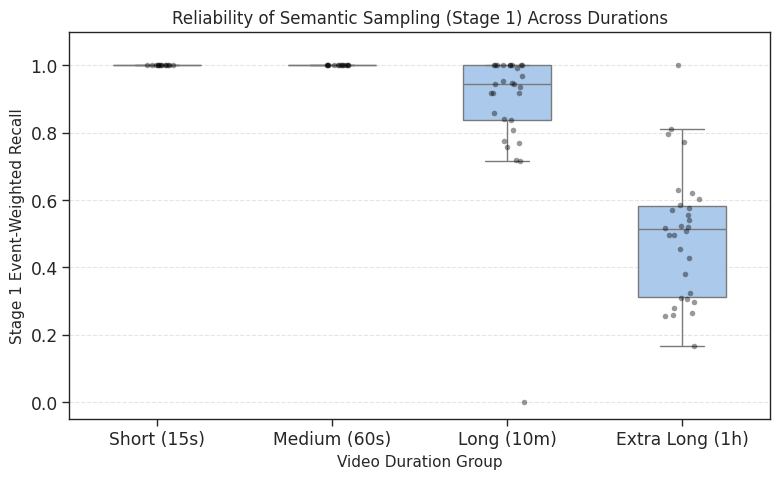

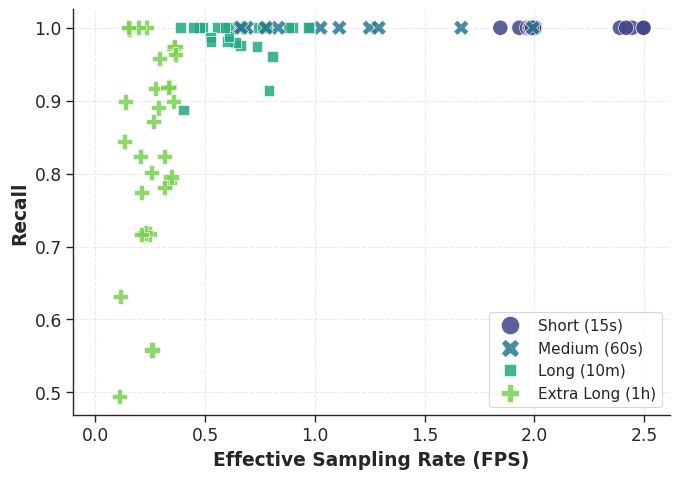

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
with open(file, 'r') as f:
    data = json.load(f)
df = pd.DataFrame(data)

# Calculate Effective FPS for Stage 1
# FPS = (Total Frames Processed) / (Video Duration)
# We derive this from the "pct" columns in the JSON
df['adaptive_fps'] = (df['frames_kept_pct'] * df['total_frames']) / df['duration']
# Recover Stage 1 FPS based on ratio
df['stage1_fps'] = df['adaptive_fps'] * (df['stage1_frames_of_uniform_pct'] / df['adaptive_frames_of_uniform_pct'])

# Create Readable Labels
duration_map = {15: 'Short (15s)', 60: 'Medium (60s)', 600: 'Long (10m)', 3600: 'Extra Long (1h)'}
df['Duration Category'] = df['duration_group'].map(duration_map)

# --- Graph 1: Reliability (Recall vs. Duration) ---
plt.figure(figsize=(8, 5))
order = ['Short (15s)', 'Medium (60s)', 'Long (10m)', 'Extra Long (1h)']

# Box Plot
sns.boxplot(x='Duration Category', y='stage1_recall', data=df, order=order, 
            color='#a1c9f4', width=0.5, showfliers=False)
# Strip Plot (for density)
sns.stripplot(x='Duration Category', y='stage1_recall', data=df, order=order, 
              color='black', alpha=0.4, size=4, jitter=True)

plt.title('Reliability of Semantic Sampling (Stage 1) Across Durations', fontsize=12)
plt.ylabel('Stage 1 Event-Weighted Recall', fontsize=11)
plt.xlabel('Video Duration Group', fontsize=11)
plt.ylim(-0.05, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('stage1_reliability.pdf', format='pdf')
plt.show()

# Calculate Effective FPS for Stage 1
df['adaptive_fps'] = (df['frames_kept_pct'] * df['total_frames']) / df['duration']
df['stage1_fps'] = df['adaptive_fps'] * (df['stage1_frames_of_uniform_pct'] / df['adaptive_frames_of_uniform_pct'])

# Create Duration Category
duration_map = {15: 'Short (15s)', 60: 'Medium (60s)', 600: 'Long (10m)', 3600: 'Extra Long (1h)'}
df['Duration Category'] = df['duration_group'].map(duration_map)

# Filter Data: Remove points with recall < 0.3
df_filtered = df[df['stage1_recall'] >= 0.2].copy()

# Set up the plot style for academic paper
sns.set_context("paper", font_scale=1.4) # Increase font scale for readability
sns.set_style("ticks") # Clean style with ticks, white background

plt.figure(figsize=(7, 5)) # Standard column width is usually ~3.5 or ~7 inches

# Define order and palette
order = ['Short (15s)', 'Medium (60s)', 'Long (10m)', 'Extra Long (1h)']
palette = sns.color_palette("viridis", n_colors=4) # viridis is standard and good

# Scatter Plot
sns.scatterplot(
    x='stage1_fps', 
    y='stage1_event_recall', 
    hue='Duration Category', 
    style='Duration Category', 
    data=df_filtered,
    palette=palette, 
    hue_order=order, 
    style_order=order,
    s=120, 
    alpha=0.85, 
    edgecolor='w', 
    linewidth=0.5
)

# Axis Labels
plt.xlabel('Effective Sampling Rate (FPS)', fontweight='bold')
plt.ylabel('Recall', fontweight='bold')

# Axis limits and grid
# plt.ylim(0.25, 1.05) # Start slightly below 0.3 to show the floor, go up to 1.05
plt.xlim(left=-0.1) 
plt.grid(True, linestyle='--', alpha=0.4)

# Legend Configuration
# Place legend inside (bottom right) to save space
plt.legend(title=None, loc='lower right', frameon=True, fontsize=11, markerscale=1.2)

# Remove top and right spines for a cleaner look
sns.despine()

plt.tight_layout()
plt.savefig('stage1_efficiency_clean.pdf', format='pdf', bbox_inches='tight')
plt.show()